# Claim Chosen: BrainBoost Gum Co.

The claim I'm testing: "Chewing our nootropic gum for 10 minutes before an exam improves memory recall scores more than chewing regular mint gum."

The outcome is a memory test score, which is continuous.

Plan for this notebook: set up the hypotheses, pick a test, find an effect size from the literature and run a power analysis to figure out how many people the study needs.

## How I would run the study

Two groups, randomly assigned. One group gets the nootropic gum and the other gets plain mint gum. The gums should look and taste the same so nobody (participant or tester) knows which is which. Everyone chews for 10 minutes, then takes the same memory test, something like a 15 word list where the score is how many words you can recall.

I went with two separate groups instead of having each person try both gums because memory tests have a practice effect. If someone takes the test twice they will probably do better the second time no matter what gum they chewed, and swapping in a different word list isn't a perfect fix for that either. Testing each person once avoids that. It also means the two groups are independent, which matters for the test I picked below.

## Hypotheses

μ_N = mean memory recall score for the nootropic gum group
μ_M = mean memory recall score for the mint gum group

**Null hypothesis (H0):** μ_N − μ_M = 0. The nootropic gum doesn't do anything different from mint gum.

**Alternative hypothesis (H1):** μ_N − μ_M > 0. The nootropic gum improves memory recall, so the mean score is greater than the mint gum group.

I made this one-sided because the claim itself is one-sided. BrainBoost says the gum improves scores, not that it changes them in some direction. The downside is a one-sided test can't catch the gum making memory worse, but since the point is to check the marketing claim I think that's fine here.

## Test

I'm going to use an independent samples t-test with Welch's correction. This works because the outcome is continuous, there are two groups, and the groups are independent since people were randomly assigned. I chose Welch's version instead of the regular pooled t-test because I have no reason to assume both groups have the same variance, and Welch's barely costs anything if the variances do turn out to be equal.

Assumptions I'm relying on:
- observations are independent (random assignment, each person tested once)
- scores in each group are roughly normal, or the sample is big enough that it doesn't matter much
- the outcome is continuous

If the scores end up really skewed or a lot of people hit the max score, I'd switch to a Mann-Whitney U test since it doesn't need normality.


## Literature and effect size

For comparing two group means the effect size measure is Cohen's d, which is the difference in means divided by the pooled standard deviation.

I used Onyper et al. (2011). They looked at whether chewing gum before a cognitive test helps recall. There were 80 undergraduates in Experiment 1a with 40 per group. The gum group chewed Wrigley's spearmint for 5 minutes to a metronome, then discarded it before testing. The memory task was 30 nouns shown one at a time showing roughly a 3 minute delay on another task, then 2 minutes of written free recall. The score was calculated by the number of words correctly recalled. The study reported a gum group mean of 8.18 and a control group mean of 5.2 with a t of 4.78 for free recall in the gum group vs. the no-gum group.

Citation: Onyper, S. V., Carr, T. L., Farrar, J. T., & Floyd, R. R. (2011). Cognitive advantages of chewing gum. Now you see them, now you don't. Appetite, 57(2), 321–328. https://doi.org/10.1016/j.appet.2011.05.313

One thing I want to call out is that the paper compared gum to no gum at all, so its effect size is really measuring the benefit of chewing. In my study both groups chew, so that part cancels out and the only difference is the nootropic ingredient. That effect is probably smaller than what the paper found. Because of that I'm treating the paper's d as a ceiling and using a more conservative d = 0.3 for the power analysis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.power import TTestIndPower

# settings for the study, explained above
alpha = 0.05
power = 0.80
alternative = "larger"  # one sided, nootropic > mint

In [2]:
# numbers from Onyper et al. 2011, free recall, gum vs no gum
gum_mean = 8.18
gum_sd = 3.19
gum_n = 40
ctrl_mean = 5.20
ctrl_sd = 2.30
ctrl_n = 40

# pooled sd then cohen's d
pooled_sd = np.sqrt(((gum_n - 1) * gum_sd**2 + (ctrl_n - 1) * ctrl_sd**2) / (gum_n + ctrl_n - 2))
d_paper = (gum_mean - ctrl_mean) / pooled_sd
print("Cohen's d from the paper =", round(d_paper, 2))


Cohen's d from the paper = 1.07


In [3]:
t_stat = 4.78
d_paper = t_stat * np.sqrt(1 / gum_n + 1 / ctrl_n)
print("Cohen's d from the paper =", round(d_paper, 2))

Cohen's d from the paper = 1.07


In [4]:
# going with a smaller d than the paper
effect_size = 0.3

analysis = TTestIndPower()
n = analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power, alternative=alternative)
n = int(np.ceil(n))

# bump it up a bit in case people drop out
dropout = 0.10
n_recruit = int(np.ceil(n / (1 - dropout)))

print("Required sample size per group:", n)
print("Total required sample size:", 2 * n)
print("With 10% dropout, recruit per group:", n_recruit, "total:", 2 * n_recruit)


Required sample size per group: 139
Total required sample size: 278
With 10% dropout, recruit per group: 155 total: 310


In [5]:
# how much does the answer move if I'm wrong about the effect size?
for d in [0.2, 0.3, 0.4, 0.5, 0.8, 1.07]:
    n_d = analysis.solve_power(effect_size=d, alpha=alpha, power=power, alternative=alternative)
    n_d = int(np.ceil(n_d))
    print("d =", d, "-> n per group =", n_d, ", total =", 2 * n_d)

d = 0.2 -> n per group = 310 , total = 620
d = 0.3 -> n per group = 139 , total = 278
d = 0.4 -> n per group = 78 , total = 156
d = 0.5 -> n per group = 51 , total = 102
d = 0.8 -> n per group = 21 , total = 42
d = 1.07 -> n per group = 12 , total = 24


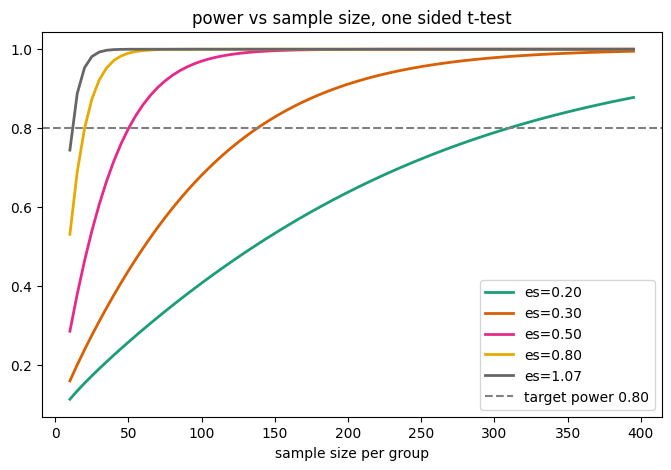

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
analysis.plot_power(dep_var="nobs", nobs=np.arange(10, 400, 5),
                    effect_size=[0.2, 0.3, 0.5, 0.8, 1.07],
                    alpha=alpha, alternative=alternative, ax=ax)
ax.axhline(power, color="gray", linestyle="--", label="target power 0.80")
ax.set_xlabel("sample size per group")
ax.set_title("power vs sample size, one sided t-test")
ax.legend()
plt.show()

## What this means for the study

Using alpha = 0.05, power = 0.80, and a conservative Cohen's d = 0.3, the required sample size is 139 participants per group, or 278 total. Adding 10% for dropout, I would recruit 155 per group, 310 total.

I want to be clear about why I didn't use the d = 1.07 from Onyper et al. (2011) directly. That number came from gum vs. no gum and the same paper found the effect basically disappeared in Experiment 1b (d = −0.11) and Experiment 2 (d = −0.16) when the timing changed. On top of that, both of my groups chew gum, so whatever chewing does cancels out and I'm only measuring the nootropic ingredient. Using 1.07 would have given a required sample size of 12 per group, which would seriously underestimate what the study actually needs..

The sensitivity check shows how much this depends on the effect size guess. If the true d is 0.2 the study needs 310 per group, more than double the plan and if it's 0.5 it only needs 51. Going with 0.3 is a middle ground that doesn't assume the ingredient works as well as chewing itself does.

Feasibility: Recruiting roughly 300 undergrads over a semester is doable for a university study with course credit or a small payment, but BrainBoost should budget for it rather than run a quick 30 person pilot to say that the claim was proven.